# BiDA Inference & Visualization
Run these cells to evaluate the trained model, generate the confusion matrix, and visualize the classification maps.

In [3]:
import torch
from models.semantic_tokenizer import HSISemanticTokenizer

tokenizer = HSISemanticTokenizer(
    num_tokens=4,
    token_dim=64,
)

# Supported: [B, bands, H, W]
hsi = torch.randn(8, 48, 13, 13)

tokens = tokenizer(hsi)
print(tokens.shape)  
tokens, attention = tokenizer(hsi, return_attention=True)

print(tokens.shape)     # [B, 4, 64]
print(attention.shape)

torch.Size([8, 4, 64])
torch.Size([8, 4, 64])
torch.Size([8, 4, 13, 13])


In [6]:
!pip install einops h5py  matplotlib seaborn scipy spectral

  Using cached spectral-0.25-py3-none-any.whl
You should consider upgrading via the '/Users/sumankar/Desktop/WS_EMCAD/.venv/bin/python3 -m pip install --upgrade pip' command.


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as io
from models.get_model import get_model
from utils.dataset import load_mat_hsi
from utils.utils_HSI import count_sliding_window, sliding_window, grouper, metrics
from tqdm import tqdm

import os


In [14]:
# Define configurations
class Opts:
    pass

opts = Opts()
opts.model = 'BiDA'
opts.source_name = 'Houston13'
opts.target_name = 'Houston18'
opts.dataset_dir = './Houston/'
opts.patch_size = 13
opts.dim = 64
opts.depth = 3
opts.num_tokens = 4

# Check for MPS or CUDA
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')


Using device: mps


In [15]:
# Load target data
print('Loading dataset...')
img_tar, gt_tar, labels = load_mat_hsi(opts.target_name, opts.dataset_dir, norm='normband')
n_classes = len(labels)

print(f'Image shape: {img_tar.shape}')
print(f'Ground truth shape: {gt_tar.shape}')
print(f'Number of classes: {n_classes}')


Loading dataset...
Loading MATLAB v7.3 file using h5py: ./Houston/Houston18.mat
Loading MATLAB v7.3 file using h5py: ./Houston/Houston18_7gt.mat
Image shape: (210, 954, 48)
Ground truth shape: (210, 954)
Number of classes: 7


In [16]:
# Find the best checkpoint model
checkpoint_dir = f'./checkpoints/{opts.model}/{opts.source_name}to{opts.target_name}'
# Find the .pth file in the directory
model_files = [f for f in os.listdir(checkpoint_dir) if f.endswith('.pth')]
if not model_files:
    raise FileNotFoundError('No checkpoint found. Did training complete?')
best_model_file = sorted(model_files)[-1] # Gets the latest/best model
checkpoint_path = os.path.join(checkpoint_dir, best_model_file)
print(f'Loading model weights from: {checkpoint_path}')

# Initialize and load weights
network = get_model(opts.model, opts.source_name, opts.patch_size, opts)
network.load_state_dict(torch.load(checkpoint_path, map_location=device))
network.to(device)
network.eval()
print('Model loaded successfully.')


Loading model weights from: ./checkpoints/BiDA/Houston13toHouston18/model_ts_best0.8098_2100.pth
Model loaded successfully.


In [23]:
# Sliding window inference
patch_size = opts.patch_size
batch_size = 128
window_size = (patch_size, patch_size)
image_w, image_h = img_tar.shape[:2]
pad_size = patch_size // 2

img_padded = np.pad(img_tar, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='reflect')
probs = np.zeros(img_padded.shape[:2] + (n_classes, ))

iterations = count_sliding_window(img_padded,step=1, window_size=window_size) // batch_size

for batch in tqdm(grouper(batch_size, sliding_window(img_padded,step=1, window_size=window_size)), 
                  total=iterations, desc='Inference'):
    with torch.no_grad():
        data = [b[0] for b in batch]
        data = np.copy(data).transpose((0, 3, 1, 2))
        data = torch.from_numpy(data).float().unsqueeze(1).to(device)
        indices = [b[1:] for b in batch]
        
        # BiDA expects 2 inputs during training, but only target matters during inference
        output = network(data, data) 
        if isinstance(output, tuple):
            output = output[1]
            
        output = output.cpu().numpy()

        for (x, y, w, h), out in zip(indices, output):
            probs[x + w // 2, y + h // 2] += out

# Crop padded area
probs = probs[pad_size:image_w + pad_size, pad_size:image_h + pad_size, :]
pred_map = np.argmax(probs, axis=-1)

# Mask out unlabeled background pixels (where gt_tar is -1)
pred_map_masked = np.copy(pred_map)
pred_map_masked[gt_tar == -1] = -1

print('Inference complete.')


































































































































































































































































































































































































































































































































































































































































































































































































































































































































Inference: 1557it [02:35, 10.01it/s]

Inference complete.


Overall Accuracy: 80.68%


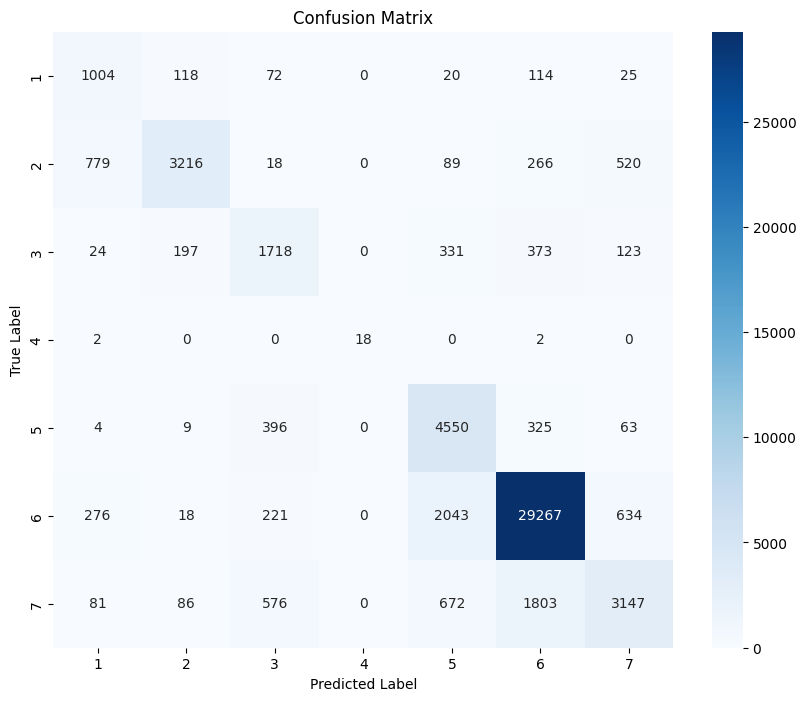

In [24]:
# Calculate and plot Confusion Matrix
# We evaluate pixels where gt_tar >= 0 (since background is -1)
valid_mask = gt_tar >= 0
y_true = gt_tar[valid_mask]  # It's already correctly 0-indexed!
y_pred = pred_map[valid_mask]

# Get metrics dictionary from utility
results = metrics(y_pred, y_true, n_classes=n_classes)

print(f'Overall Accuracy: {results["Accuracy"]:.2f}%')

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
cm = results['Confusion_matrix']
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Exception ignored in: <function tqdm.__del__ at 0x10e043af0>
Traceback (most recent call last):
  File "/Users/sumankar/Desktop/WS_EMCAD/.venv/lib/python3.9/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/sumankar/Desktop/WS_EMCAD/.venv/lib/python3.9/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


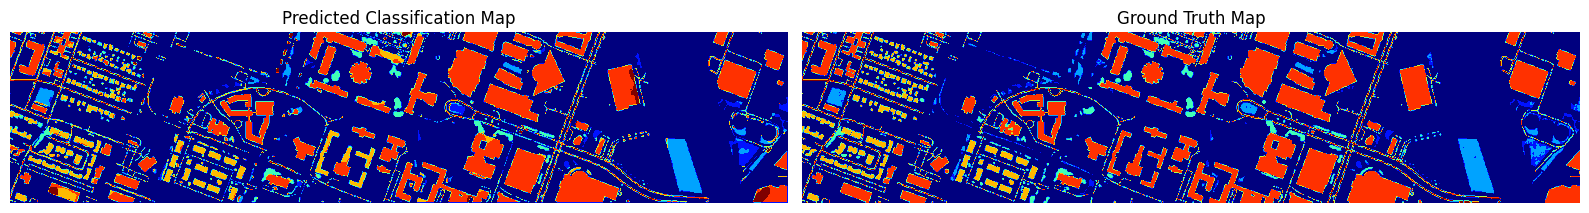

In [25]:
# Visualize Classification Maps
plt.figure(figsize=(16, 8))

# Define a discrete colormap for HSI
cmap = plt.get_cmap('jet', n_classes + 1)

plt.subplot(1, 2, 1)
plt.title('Predicted Classification Map')
# vmin and vmax set to properly handle the -1 background
plt.imshow(pred_map_masked, cmap=cmap, vmin=-1, vmax=n_classes-1)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Ground Truth Map')
plt.imshow(gt_tar, cmap=cmap, vmin=-1, vmax=n_classes-1)
plt.axis('off')

plt.tight_layout()
plt.show()
